In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
sys.path.append(str(project_root / 'src'))

from env import *
from agents.train_dqn import train_dqn, DQNConfig
from agents.experiment import Experiment

In [2]:
df_train = pd.read_csv('../data/raw/binance_BTCUSDT_1h_2021.csv')
df_test = pd.read_csv('../data/raw/binance_BTCUSDT_1h_2022.csv')

df_train.head()

,open,high,low,close,volume
0,28923.63,29031.34,28690.17,28995.13,2311.811445
1,28995.13,29470.00,28960.35,29409.99,5403.068471
2,29410.00,29465.26,29120.03,29194.65,2384.231560
3,29195.25,29367.00,29150.02,29278.40,1461.345077
4,29278.41,29395.00,29029.40,29220.31,2038.046803


In [3]:
# env_train = MyTradingEnv(df_train, window_size=10, max_steps=2500)
# env_train = SharpeReward(df_train, window_size=10, max_steps=2500)
# env_train = ReturnReward(df_train, window_size=10, max_steps=2500)
env_train = DrawdownAwareReward(df_train, window_size=10, max_steps=2500)
env_train.clear_history()
config = DQNConfig(total_timesteps=30_000)

exp = Experiment("dqn-drawdown")
result = train_dqn(env_train, config, exp)
result['model']

Using cpu device
Logging to /home/twisted/Code/ml/DeepRLTradingResearch/experiments/dqn-drawdown/20260331-130608-5fd6f5
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.5e+03  |
|    ep_rew_mean      | -191     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 639      |
|    time_elapsed     | 15       |
|    total_timesteps  | 10000    |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 3.83     |
|    n_updates        | 2249     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.5e+03  |
|    ep_rew_mean      | 12.7     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 599      |
|    time_elapsed     | 33       |
|    total_timesteps  | 20000    |
| tra

In [4]:
import seaborn as sns

sns.set_theme(style='whitegrid')

train_steps = env_train.get_steps_df()
train_steps.head()

,episode,step,df_index,action,reward,terminated,truncated,portfolio_value,cash,position,units,entry_price,position_value,holding_time,current_price,n_trades,last_exit_reason,unrealized_pnl
0,1,1,870,0,0.000000,False,False,1000.000000,1.000000e+03,0,0.000000,0.00000,0.000000,0,39267.47,0,None,0.000000
1,1,2,871,2,0.000000,False,False,1000.000000,1.000000e+03,0,0.000000,0.00000,0.000000,0,39359.12,0,None,0.000000
2,1,3,872,1,-0.599700,False,False,999.400300,2.273182e-14,1,0.025349,39444.73251,999.400300,0,39425.02,0,None,-0.499700
3,1,4,873,1,11.733980,False,False,1011.134280,2.273182e-14,1,0.025349,39444.73251,1011.134280,1,39887.91,0,None,11.234280
4,1,5,874,1,2.806685,False,False,1013.940965,2.273182e-14,1,0.025349,39444.73251,1013.940965,2,39998.63,0,None,14.040965


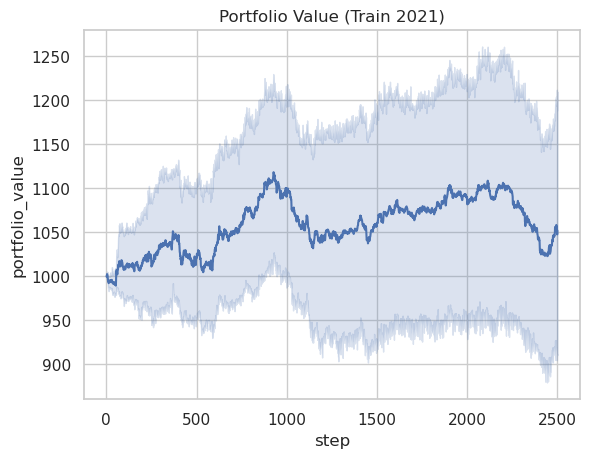

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

sns.lineplot(data=train_steps, x='step', y='portfolio_value')
plt.title('Portfolio Value (Train 2021)')
plt.show()
